# 01b - Laws Graph Exploration

Questo notebook esplora il grafo delle leggi prodotto dalla fase 1. I nodi sono leggi regionali, gli archi sono relazioni esplicite estratte da hyperlink, note e citazioni testuali.

L'obiettivo non e sostituire il dataset pulito, ma renderlo ispezionabile: conteggi, distribuzioni, centralita semplici, esempi reali e una vista HTML interattiva del grafo.

## Setup

Il notebook legge solo `data/laws_dataset_clean/` e scrive artifact derivati nella stessa directory. Il corpus sorgente `data/laws_html/` non viene modificato.

In [1]:
from __future__ import annotations

import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import HTML, IFrame, display
from pyvis.network import Network

NOTEBOOK_CWD = Path.cwd()
ROOT = next(path for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents] if (path / "pyproject.toml").exists())
DATASET_DIR = ROOT / "data" / "laws_dataset_clean"
MANIFEST_PATH = DATASET_DIR / "manifest.json"
LAWS_PATH = DATASET_DIR / "laws.jsonl"
EDGES_PATH = DATASET_DIR / "edges.jsonl"
GRAPH_HTML_PATH = DATASET_DIR / "laws_graph.html"
FOCUS_GRAPH_HTML_PATH = DATASET_DIR / "laws_graph_focus.html"

# Rendering controls. The full graph is analyzed, while PyVis receives a readable subgraph when needed.
MAX_VIS_EDGES = 700
TOP_N_NODES = 140
MAX_FOCUS_NODES = 120
FOCUS_LAW_ID = None
FOCUS_RADIUS = 1


## Caricamento degli artifact

`manifest.json` conferma che il dataset della fase 1 ha superato i quality gate. `laws.jsonl` diventa la tabella dei nodi, `edges.jsonl` la tabella degli archi diretti.

In [2]:
with MANIFEST_PATH.open(encoding="utf-8") as handle:
    manifest = json.load(handle)

laws = pd.read_json(LAWS_PATH, lines=True).sort_values("law_id").reset_index(drop=True)
edges = pd.read_json(EDGES_PATH, lines=True).sort_values("edge_id").reset_index(drop=True)

if not manifest.get("ready_for_indexing"):
    display(HTML("<strong>Warning:</strong> il manifest non segnala ready_for_indexing=true."))

summary = pd.DataFrame(
    [
        {"artifact": "manifest laws", "count": manifest["counts"]["laws"]},
        {"artifact": "loaded laws", "count": len(laws)},
        {"artifact": "manifest edges", "count": manifest["counts"]["edges"]},
        {"artifact": "loaded edges", "count": len(edges)},
        {"artifact": "self loops", "count": int((edges["src_law_id"] == edges["dst_law_id"]).sum())},
    ]
)
display(summary)

assert len(laws) == manifest["counts"]["laws"]
assert len(edges) == manifest["counts"]["edges"]
assert (edges["src_law_id"] != edges["dst_law_id"]).all()


,artifact,count
0,manifest laws,3145
1,loaded laws,3145
2,manifest edges,35159
3,loaded edges,35159
4,self loops,0


## Costruzione del grafo

Il grafo completo e un `MultiDiGraph`: mantiene relazioni multiple tra la stessa coppia di leggi. Per alcune metriche usiamo anche una vista collassata `DiGraph`, dove conta solo l'esistenza della connessione.

In [3]:
laws_by_id = laws.set_index("law_id").to_dict(orient="index")

multi_graph = nx.MultiDiGraph()
for law_id, attrs in laws_by_id.items():
    multi_graph.add_node(law_id, **attrs)

for row in edges.itertuples(index=False):
    multi_graph.add_edge(
        row.src_law_id,
        row.dst_law_id,
        key=row.edge_id,
        edge_id=row.edge_id,
        relation_type=row.relation_type,
        confidence=float(row.confidence),
        context=row.context,
        evidence_text=row.evidence_text,
        source_file=row.source_file,
    )

simple_graph = nx.DiGraph()
simple_graph.add_nodes_from(multi_graph.nodes(data=True))
simple_graph.add_edges_from((src, dst) for src, dst in edges[["src_law_id", "dst_law_id"]].itertuples(index=False, name=None))

graph_counts = pd.DataFrame(
    [
        {"graph": "MultiDiGraph", "nodes": multi_graph.number_of_nodes(), "edges": multi_graph.number_of_edges()},
        {"graph": "DiGraph collapsed", "nodes": simple_graph.number_of_nodes(), "edges": simple_graph.number_of_edges()},
    ]
)
display(graph_counts)

assert multi_graph.number_of_nodes() > 0
assert multi_graph.number_of_edges() > 0


,graph,nodes,edges
0,MultiDiGraph,3145,35159
1,DiGraph collapsed,3145,14005


## Distribuzioni principali

`law_status` descrive lo stato della legge nel dataset pulito. `relation_type` descrive il tipo di relazione esplicita osservata nel testo o nelle note.

,law_status,laws
0,current,2404
1,past,730
2,unknown,11


,relation_type,edges
0,REFERENCES,13295
1,AMENDS,6283
2,ABROGATED_BY,5984
3,REPLACES,2715
4,MODIFIED_BY,2378
5,REPLACED_BY,2223
6,INSERTS,1371
7,INSERTED_BY,720
8,ABROGATES,190


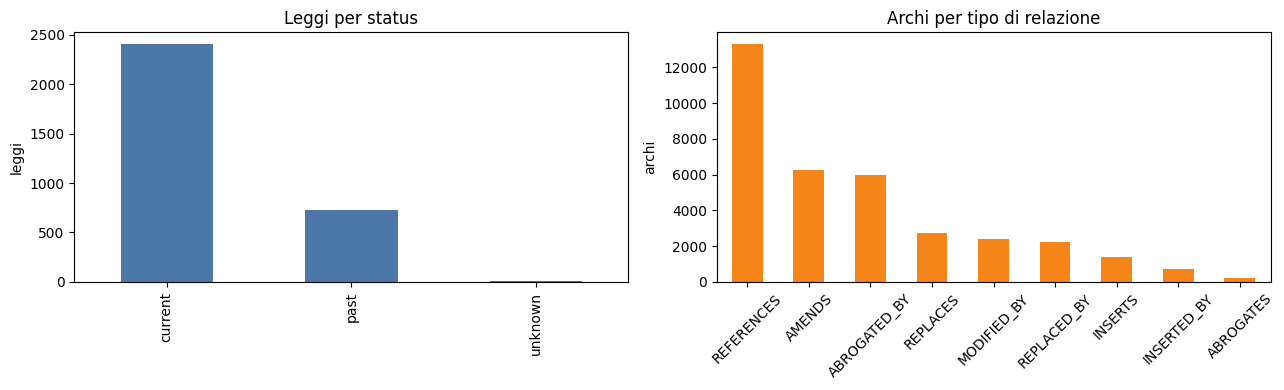

In [4]:
status_distribution = laws["law_status"].value_counts().rename_axis("law_status").reset_index(name="laws")
relation_distribution = edges["relation_type"].value_counts().rename_axis("relation_type").reset_index(name="edges")

display(status_distribution)
display(relation_distribution)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
status_distribution.plot.bar(x="law_status", y="laws", ax=axes[0], legend=False, color="#4c78a8")
axes[0].set_title("Leggi per status")
axes[0].set_xlabel("")
axes[0].set_ylabel("leggi")

relation_distribution.plot.bar(x="relation_type", y="edges", ax=axes[1], legend=False, color="#f58518")
axes[1].set_title("Archi per tipo di relazione")
axes[1].set_xlabel("")
axes[1].set_ylabel("archi")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Centralita semplice

In-degree: quante relazioni entrano in una legge. Out-degree: quante relazioni escono da una legge. Total degree: quanto una legge e complessivamente connessa nel grafo estratto.

In [5]:
in_counts = edges.groupby("dst_law_id").size().rename("in_degree")
out_counts = edges.groupby("src_law_id").size().rename("out_degree")

node_metrics = (
    laws[["law_id", "law_date", "law_number", "law_title", "law_status"]]
    .merge(in_counts, left_on="law_id", right_index=True, how="left")
    .merge(out_counts, left_on="law_id", right_index=True, how="left")
    .fillna({"in_degree": 0, "out_degree": 0})
)
node_metrics["in_degree"] = node_metrics["in_degree"].astype(int)
node_metrics["out_degree"] = node_metrics["out_degree"].astype(int)
node_metrics["total_degree"] = node_metrics["in_degree"] + node_metrics["out_degree"]

display(node_metrics.sort_values(["in_degree", "law_date", "law_number"], ascending=[False, True, True]).head(15))
display(node_metrics.sort_values(["out_degree", "law_date", "law_number"], ascending=[False, True, True]).head(15))
display(node_metrics.sort_values(["total_degree", "law_date", "law_number"], ascending=[False, True, True]).head(15))


,law_id,law_date,law_number,law_title,law_status,in_degree,out_degree,total_degree
2471,vda:lr:2002-10-14:19,2002-10-14,19,"Legge regionale 14 ottobre 2002, n. 19 - Testo...",current,1408,1168,2576
2172,vda:lr:1995-11-20:48,1995-11-20,48,"Legge regionale 20 novembre 1995, n. 48 - Test...",current,700,94,794
2281,vda:lr:1998-04-06:11,1998-04-06,11,"Legge regionale 6 aprile 1998, n. 11 - Testo v...",current,693,456,1149
2419,vda:lr:2001-04-17:7,2001-04-17,7,"Legge regionale 17 aprile 2001, n. 7 - Testo v...",current,588,426,1014
2169,vda:lr:1995-10-23:45,1995-10-23,45,"Legge regionale 23 ottobre 1995, n. 45 - Testo...",current,531,222,753
2748,vda:lr:2010-07-23:22,2010-07-23,22,"Legge regionale 23 luglio 2010, n. 22 - Testo ...",current,530,252,782
2325,vda:lr:1998-12-07:54,1998-12-07,54,"Legge regionale 7 dicembre 1998, n. 54 - Testo...",current,460,401,861
2187,vda:lr:1996-06-20:12,1996-06-20,12,"Legge regionale 20 giugno 1996, n. 12 - Testo ...",past,326,326,652
1685,vda:lr:1989-12-27:90,1989-12-27,90,"Legge regionale 27 dicembre 1989, n. 90 - Test...",past,281,2,283
2627,vda:lr:2007-08-06:19,2007-08-06,19,"Legge regionale 6 agosto 2007, n. 19 - Testo v...",current,274,140,414


,law_id,law_date,law_number,law_title,law_status,in_degree,out_degree,total_degree
2471,vda:lr:2002-10-14:19,2002-10-14,19,"Legge regionale 14 ottobre 2002, n. 19 - Testo...",current,1408,1168,2576
2281,vda:lr:1998-04-06:11,1998-04-06,11,"Legge regionale 6 aprile 1998, n. 11 - Testo v...",current,693,456,1149
2419,vda:lr:2001-04-17:7,2001-04-17,7,"Legge regionale 17 aprile 2001, n. 7 - Testo v...",current,588,426,1014
2325,vda:lr:1998-12-07:54,1998-12-07,54,"Legge regionale 7 dicembre 1998, n. 54 - Testo...",current,460,401,861
2187,vda:lr:1996-06-20:12,1996-06-20,12,"Legge regionale 20 giugno 1996, n. 12 - Testo ...",past,326,326,652
2748,vda:lr:2010-07-23:22,2010-07-23,22,"Legge regionale 23 luglio 2010, n. 22 - Testo ...",current,530,252,782
2128,vda:lr:1995-02-09:4,1995-02-09,4,"Legge regionale 9 febbraio 1995, n. 4 - Testo ...",current,246,247,493
2994,vda:lr:2020-07-13:8,2020-07-13,8,"Legge regionale 13 luglio 2020, n. 8 - Testo v...",current,139,239,378
2169,vda:lr:1995-10-23:45,1995-10-23,45,"Legge regionale 23 ottobre 1995, n. 45 - Testo...",current,531,222,753
2569,vda:lr:2005-12-05:31,2005-12-05,31,"Legge regionale 5 dicembre 2005, n. 31 - Testo...",current,134,219,353


,law_id,law_date,law_number,law_title,law_status,in_degree,out_degree,total_degree
2471,vda:lr:2002-10-14:19,2002-10-14,19,"Legge regionale 14 ottobre 2002, n. 19 - Testo...",current,1408,1168,2576
2281,vda:lr:1998-04-06:11,1998-04-06,11,"Legge regionale 6 aprile 1998, n. 11 - Testo v...",current,693,456,1149
2419,vda:lr:2001-04-17:7,2001-04-17,7,"Legge regionale 17 aprile 2001, n. 7 - Testo v...",current,588,426,1014
2325,vda:lr:1998-12-07:54,1998-12-07,54,"Legge regionale 7 dicembre 1998, n. 54 - Testo...",current,460,401,861
2172,vda:lr:1995-11-20:48,1995-11-20,48,"Legge regionale 20 novembre 1995, n. 48 - Test...",current,700,94,794
2748,vda:lr:2010-07-23:22,2010-07-23,22,"Legge regionale 23 luglio 2010, n. 22 - Testo ...",current,530,252,782
2169,vda:lr:1995-10-23:45,1995-10-23,45,"Legge regionale 23 ottobre 1995, n. 45 - Testo...",current,531,222,753
2187,vda:lr:1996-06-20:12,1996-06-20,12,"Legge regionale 20 giugno 1996, n. 12 - Testo ...",past,326,326,652
2128,vda:lr:1995-02-09:4,1995-02-09,4,"Legge regionale 9 febbraio 1995, n. 4 - Testo ...",current,246,247,493
1958,vda:lr:1993-01-12:3,1993-01-12,3,"Legge regionale 12 gennaio 1993, n. 3 - Testo ...",current,240,202,442


## Componenti connesse

Le componenti sono calcolate sulla vista non diretta del grafo collassato. Servono a capire se le leggi formano un unico blocco relazionale o piu isole separate.

In [6]:
components = sorted(nx.connected_components(simple_graph.to_undirected()), key=len, reverse=True)
component_rows = []
for idx, component in enumerate(components[:15], start=1):
    sub = simple_graph.subgraph(component)
    component_rows.append({"component": idx, "nodes": sub.number_of_nodes(), "edges": sub.number_of_edges()})

component_profile = pd.DataFrame(component_rows)
display(component_profile)


,component,nodes,edges
0,1,3044,13982
1,2,3,3
2,3,3,5
3,4,2,2
4,5,2,2
5,6,2,2
6,7,2,1
7,8,2,2
8,9,2,2
9,10,2,2


## Esempi reali di relazioni

Gli archi non sono inferenze libere: ogni relazione conserva evidenza testuale, contesto di estrazione e confidenza.

In [7]:
edge_examples = edges.merge(
    laws[["law_id", "law_title", "law_status"]].rename(
        columns={"law_id": "src_law_id", "law_title": "src_law_title", "law_status": "src_law_status"}
    ),
    on="src_law_id",
    how="left",
).merge(
    laws[["law_id", "law_title", "law_status"]].rename(
        columns={"law_id": "dst_law_id", "law_title": "dst_law_title", "law_status": "dst_law_status"}
    ),
    on="dst_law_id",
    how="left",
)

display(
    edge_examples[
        [
            "relation_type",
            "context",
            "confidence",
            "src_law_title",
            "dst_law_title",
            "evidence_text",
        ]
    ]
    .sort_values(["relation_type", "confidence"], ascending=[True, False])
    .head(12)
)


,relation_type,context,confidence,src_law_title,dst_law_title,evidence_text
2,ABROGATED_BY,passage,0.9,"Legge regionale 4 agosto 1982, n. 33 - Testo v...","Legge regionale 15 maggio 1974, n. 13 - Testo ...","Legge regionale 4 agosto 1982, n. 33 - Testo v..."
13,ABROGATED_BY,passage,0.9,"Legge regionale 22 novembre 1984, n. 60 - Test...","Legge regionale 14 ottobre 2002, n. 19 - Testo...","Legge regionale 22 novembre 1984, n. 60 - Test..."
28,ABROGATED_BY,passage,0.9,"Legge regionale 3 maggio 1993, n. 25 - Testo v...","Legge regionale 16 giugno 1988, n. 47 - Testo ...","Legge regionale 3 maggio 1993, n. 25 - Testo v..."
44,ABROGATED_BY,preamble,0.9,"Legge regionale 30 ottobre 1987, n. 86 - Testo...","Legge regionale 8 gennaio 2001, n. 1 - Testo v...",(Abrogata dall'art. 26 della L.R. 8 gennaio 20...
48,ABROGATED_BY,note,0.9,"Legge regionale 30 luglio 1986, n. 36 - Testo ...","Legge regionale 19 marzo 2018, n. 2 - Testo vi...","(4a) Comma abrogato dall'art. 2, comma 2, dell..."
53,ABROGATED_BY,note,0.9,"Legge regionale 15 dicembre 2003, n. 21 - Test...","Legge regionale 27 novembre 1990, n. 75 - Test...",(40) Articolo abrogato dall'art. 8 della L.R. ...
56,ABROGATED_BY,preamble,0.9,"Legge regionale 3 agosto 1972, n. 21 - Testo v...","Legge regionale 23 ottobre 1995, n. 45 - Testo...",(Abrogata dall'art. 65 della L.R. 23 ottobre 1...
61,ABROGATED_BY,passage,0.9,"Legge regionale 10 novembre 1966, n. 15 - Test...","Legge regionale 14 ottobre 2002, n. 19 - Testo...","Legge regionale 10 novembre 1966, n. 15 - Test..."
70,ABROGATED_BY,passage,0.9,"Legge regionale 21 agosto 1990, n. 60 - Testo ...","Legge regionale 16 giugno 1988, n. 44 - Testo ...","Legge regionale 21 agosto 1990, n. 60 - Testo ..."
81,ABROGATED_BY,preamble,0.9,"Legge regionale 29 dicembre 1975, n. 55 - Test...","Legge regionale 5 ottobre 2012, n. 28 - Testo ...",(Abrogata dall'art. 3 della L.R. 5 ottobre 201...


## Funzioni per la visualizzazione PyVis

PyVis produce un file HTML interattivo. Il notebook usa colori stabili per status e tipo relazione, dimensiona i nodi per grado e mette le informazioni principali nei tooltip.

In [8]:
STATUS_COLORS = {
    "current": "#2f855a",
    "past": "#718096",
    "unknown": "#b7791f",
    "index_or_empty": "#805ad5",
}

RELATION_COLORS = {
    "REFERENCES": "#718096",
    "ABROGATED_BY": "#c53030",
    "ABROGATES": "#e53e3e",
    "MODIFIED_BY": "#2b6cb0",
    "AMENDS": "#3182ce",
    "REPLACED_BY": "#b7791f",
    "REPLACES": "#d69e2e",
    "INSERTED_BY": "#6b46c1",
    "INSERTS": "#805ad5",
}

def shorten(value: object, limit: int = 220) -> str:
    text = " ".join(str(value or "").split())
    return text if len(text) <= limit else text[: limit - 1] + "..."


def edge_subset_for_nodes(selected_nodes: set[str], max_edges: int) -> pd.DataFrame:
    subset = edges[edges["src_law_id"].isin(selected_nodes) & edges["dst_law_id"].isin(selected_nodes)].copy()
    if subset.empty:
        return subset
    subset = (
        subset.sort_values(["confidence", "edge_id"], ascending=[False, True])
        .groupby(["src_law_id", "dst_law_id", "relation_type"], as_index=False)
        .agg(
            confidence=("confidence", "max"),
            context=("context", "first"),
            evidence_text=("evidence_text", "first"),
            edge_id=("edge_id", "first"),
            evidence_count=("edge_id", "size"),
        )
    )
    subset["visual_weight"] = subset["confidence"] * (1 + subset["evidence_count"].clip(upper=25).map(math.log1p))
    subset = subset.sort_values(["visual_weight", "confidence", "evidence_count"], ascending=False)
    return subset.head(max_edges)


def timeline_positions(selected_nodes: list[str], edge_subset: pd.DataFrame) -> dict[str, tuple[float, float]]:
    """Place laws on a chronological x-axis and separate connected laws vertically."""
    subgraph = nx.Graph()
    subgraph.add_nodes_from(selected_nodes)
    subgraph.add_edges_from(edge_subset[["src_law_id", "dst_law_id"]].itertuples(index=False, name=None))

    law_dates = pd.to_datetime(
        [laws_by_id.get(law_id, {}).get("law_date") for law_id in selected_nodes],
        errors="coerce",
    )
    valid_dates = law_dates.dropna()
    min_date = valid_dates.min() if len(valid_dates) else pd.Timestamp("1950-01-01")
    max_date = valid_dates.max() if len(valid_dates) else min_date + pd.Timedelta(days=1)
    date_span = max((max_date - min_date).days, 1)
    width = max(2600, 34 * len(selected_nodes))
    lane_gap = 72
    component_gap = 620
    components = sorted(nx.connected_components(subgraph), key=len, reverse=True)
    component_offsets = {
        law_id: (component_index, sorted(component))
        for component_index, component in enumerate(components)
        for law_id in component
    }

    positions = {}
    for law_id, law_date in zip(selected_nodes, law_dates):
        if pd.isna(law_date):
            x = 0.0
        else:
            x = (((law_date - min_date).days / date_span) - 0.5) * width
        component_index, component_nodes = component_offsets[law_id]
        sorted_component = sorted(
            component_nodes,
            key=lambda node: (laws_by_id.get(node, {}).get("law_date") or "9999", laws_by_id.get(node, {}).get("law_number") or ""),
        )
        lane_count = max(5, min(48, math.ceil(math.sqrt(len(sorted_component))) * 3))
        lane_index = sorted_component.index(law_id) % lane_count
        component_center = (component_index - (len(components) - 1) / 2) * component_gap
        y = component_center + (lane_index - (lane_count - 1) / 2) * lane_gap
        positions[law_id] = (float(x), float(y))
    return positions


def make_pyvis_graph(edge_subset: pd.DataFrame, output_path: Path, title: str) -> Network:
    selected_nodes = sorted(set(edge_subset["src_law_id"]) | set(edge_subset["dst_law_id"]))
    positions = timeline_positions(selected_nodes, edge_subset)
    net = Network(
        height="900px",
        width="100%",
        directed=True,
        notebook=False,
        cdn_resources="in_line",
        bgcolor="#ffffff",
        select_menu=True,
        filter_menu=True,
    )
    net.heading = title

    metrics_by_id = node_metrics.set_index("law_id").to_dict(orient="index")
    for law_id in selected_nodes:
        law = laws_by_id.get(law_id, {})
        metrics = metrics_by_id.get(law_id, {})
        total_degree = int(metrics.get("total_degree", 0))
        size = 8 + min(24, 2.8 * math.sqrt(max(total_degree, 1)))
        status = law.get("law_status", "unknown")
        x, y = positions[law_id]
        title_html = (
            f"<strong>{shorten(law.get('law_title'), 180)}</strong><br>"
            f"ID: {law_id}<br>"
            f"Data: {law.get('law_date')} - n. {law.get('law_number')}<br>"
            f"Status: {status}<br>"
            f"In: {metrics.get('in_degree', 0)} | Out: {metrics.get('out_degree', 0)}"
        )
        net.add_node(
            law_id,
            label=f"{law.get('law_date', '')} n.{law.get('law_number', '')}",
            title=title_html,
            color=STATUS_COLORS.get(status, STATUS_COLORS["unknown"]),
            size=size,
            value=max(total_degree, 1),
            x=x,
            y=y,
            fixed={"x": True, "y": True},
        )

    for row in edge_subset.itertuples(index=False):
        relation = row.relation_type
        edge_title = (
            f"<strong>{relation}</strong><br>"
            f"Aggregated evidence rows: {getattr(row, 'evidence_count', 1)}<br>"
            f"Context: {row.context}<br>"
            f"Confidence: {row.confidence:.2f}<br>"
            f"Evidence: {shorten(row.evidence_text, 360)}"
        )
        net.add_edge(
            row.src_law_id,
            row.dst_law_id,
            title=edge_title,
            color=RELATION_COLORS.get(relation, "#718096"),
            value=max(float(row.confidence), 0.2),
            width=max(0.3, min(1.4, float(row.confidence))),
            arrows="to",
        )

    net.set_options(
        """
        {
          "layout": {"randomSeed": 42},
          "nodes": {
            "shape": "dot",
            "borderWidth": 1,
            "font": {"size": 14, "face": "arial", "strokeWidth": 4, "strokeColor": "#ffffff"},
            "scaling": {"label": {"enabled": true, "min": 11, "max": 22, "drawThreshold": 9, "maxVisible": 45}}
          },
          "edges": {
            "color": {"inherit": false, "opacity": 0.28},
            "hoverWidth": 1.6,
            "selectionWidth": 2.2,
            "smooth": {"enabled": true, "type": "curvedCW", "roundness": 0.12},
            "font": {"size": 0},
            "arrows": {"to": {"enabled": true, "scaleFactor": 0.45}}
          },
          "interaction": {
            "hover": true,
            "tooltipDelay": 80,
            "navigationButtons": true,
            "keyboard": true,
            "multiselect": true,
            "hideEdgesOnDrag": true,
            "hideEdgesOnZoom": true
          },
          "physics": {"enabled": false}
        }
        """
    )
    net.write_html(str(output_path), notebook=False, open_browser=False)
    return net


## Grafo interattivo principale

Il dataset completo viene sempre analizzato. Per la visualizzazione HTML, se il grafo completo supera la soglia di leggibilita, viene creato un sottografo indotto dalle leggi piu connesse.

In [9]:
if len(edges) <= MAX_VIS_EDGES:
    visual_edges = edges.copy()
    visual_mode = "full graph"
else:
    top_nodes = set(
        node_metrics.sort_values(["total_degree", "in_degree", "law_date"], ascending=[False, False, True])
        .head(TOP_N_NODES)["law_id"]
    )
    visual_edges = edge_subset_for_nodes(top_nodes, MAX_VIS_EDGES)
    visual_mode = f"top-{TOP_N_NODES} connected laws, capped at {MAX_VIS_EDGES} edges"

make_pyvis_graph(visual_edges, GRAPH_HTML_PATH, f"Laws graph - {visual_mode}")

display(
    pd.DataFrame(
        [
            {
                "html_output": str(GRAPH_HTML_PATH.relative_to(ROOT)),
                "mode": visual_mode,
                "visual_nodes": len(set(visual_edges["src_law_id"]) | set(visual_edges["dst_law_id"])),
                "visual_edges": len(visual_edges),
                "full_nodes": multi_graph.number_of_nodes(),
                "full_edges": multi_graph.number_of_edges(),
            }
        ]
    )
)

assert GRAPH_HTML_PATH.exists()
IFrame(src=os.path.relpath(GRAPH_HTML_PATH, NOTEBOOK_CWD), width="100%", height=780)


,html_output,mode,visual_nodes,visual_edges,full_nodes,full_edges
0,data/laws_dataset_clean/laws_graph.html,"top-140 connected laws, capped at 700 edges",136,700,3145,35159


## Sottografo focalizzato

Per leggere meglio le relazioni, scegliamo una legge centrale. Se `FOCUS_LAW_ID` e `None`, viene usata la legge con grado totale piu alto. Il sottografo include predecessori e successori diretti.

In [10]:
focus_law_id = FOCUS_LAW_ID or node_metrics.sort_values("total_degree", ascending=False).iloc[0]["law_id"]
if focus_law_id not in simple_graph:
    raise ValueError(f"FOCUS_LAW_ID not found in graph: {focus_law_id}")

focus_nodes = {focus_law_id}
frontier = {focus_law_id}
for _ in range(FOCUS_RADIUS):
    next_frontier: set[str] = set()
    for node in frontier:
        next_frontier.update(simple_graph.predecessors(node))
        next_frontier.update(simple_graph.successors(node))
    focus_nodes.update(next_frontier)
    frontier = next_frontier

if len(focus_nodes) > MAX_FOCUS_NODES:
    ranked_neighbors = (
        node_metrics[node_metrics["law_id"].isin(focus_nodes - {focus_law_id})]
        .sort_values(["total_degree", "in_degree", "law_date"], ascending=[False, False, True])
        .head(MAX_FOCUS_NODES - 1)["law_id"]
    )
    focus_nodes = {focus_law_id, *ranked_neighbors}

focus_edges = edge_subset_for_nodes(focus_nodes, MAX_VIS_EDGES)
make_pyvis_graph(focus_edges, FOCUS_GRAPH_HTML_PATH, f"Focus graph - {focus_law_id}")

display(node_metrics[node_metrics["law_id"] == focus_law_id])
display(
    pd.DataFrame(
        [
            {
                "html_output": str(FOCUS_GRAPH_HTML_PATH.relative_to(ROOT)),
                "focus_law_id": focus_law_id,
                "focus_nodes": len(focus_nodes),
                "focus_edges": len(focus_edges),
            }
        ]
    )
)

assert FOCUS_GRAPH_HTML_PATH.exists()
IFrame(src=os.path.relpath(FOCUS_GRAPH_HTML_PATH, NOTEBOOK_CWD), width="100%", height=780)


,law_id,law_date,law_number,law_title,law_status,in_degree,out_degree,total_degree
2471,vda:lr:2002-10-14:19,2002-10-14,19,"Legge regionale 14 ottobre 2002, n. 19 - Testo...",current,1408,1168,2576


,html_output,focus_law_id,focus_nodes,focus_edges
0,data/laws_dataset_clean/laws_graph_focus.html,vda:lr:2002-10-14:19,120,271


## Note interpretative

- Il grafo rappresenta riferimenti espliciti osservati nel corpus, non una ricostruzione completa e autoritativa della vigenza normativa.
- Le relazioni dipendono dalla qualita del markup, delle note e delle citazioni testuali presenti negli HTML.
- Le metriche di grado indicano centralita nel corpus estratto, non importanza giuridica assoluta.
- Per figure di tesi conviene usare sottografi filtrati per relazione, status o legge di interesse, per evitare visualizzazioni troppo dense.